#Fundamentos de Data Science
##Analizando la Rotación de Clientes en Telecomunicaciones

###Requisitos

Tu tarea es limpiar y explorar un dataset para los ejecutivos de una empresa de telecomunicaciones que describe tendencias en la rotación de sus clientes.

El dataset puede ser encontrado aquí.
[descargar Aquí](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

1. Limpieza de datos con Python:
* Identificar y solucionar cualquier valor duplicado.
*Asegurarse de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.
* Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).
* Identificar y solucionar cualquier valor faltante en el dataset. Rellenar los valores faltantes con un marcador adecuado para el tipo de dato.
* Identificar y solucionar cualquier punto de dato inapropiado o inusual (ejemplo: la edad no puede ser 325).

2. Exploración de datos con Python:
* Crear dos tipos diferentes de visualizaciones exploratorias univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.
* Crear dos tipos diferentes de visualizaciones exploratorias multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

###Entrega

* Un archivo .ipynb claramente comentado con todo el código utilizado para la limpieza y exploración de datos. Para cumplir con los requisitos anteriores, este archivo tendrá un mínimo de 4 visualizaciones.
* Subir un repositorio a una plataforma de control de versiones (por ejemplo, GitHub) con un TAG incluido para verificar la fecha de entrega. El repositorio debe contener el archivo .ipynb.
* NOTA: Debes enviar un archivo y un enlace al repositorio con el TAG correspondiente. Las presentaciones de enlaces sin el archivo o sin el TAG serán consideradas no presentadas.

Notas

* Para evitar que otros estudiantes copien tu trabajo, asegúrate de que el código no esté guardado en un repositorio público.
* Para minimizar la deducción de puntos, asegúrate de cargar los requisitos completos.
* Si tienes problemas para cargar archivos en la aplicación de exámenes, por favor NO desbloquees otro examen. Envía el archivo por correo electrónico a tu instructor.
* Puedes usar cualquier recurso que tengas disponible (notas de clase, Google, Stackoverflow, etc.) – PERO DEBES CITAR CUALQUIER FUENTE UTILIZADA. Puedes citar fuentes en forma de comentario de código o una celda de texto con enlaces a cualquier recurso que hayas utilizado. La falta de citas será considerada plagio y resultará en la falla del examen.
* No puedes recibir ayuda de ninguna otra persona en este código. Esto incluye compañeros de clase, exalumnos, tu instructor, etc. La colaboración con otra persona en este examen será considerada plagio y resultará en la falla del examen y puede resultar en la expulsión del programa.
* Se permite el uso de LLM (Copilot, GPT, etc.), pero solo como guía o para depuración. Se espera que los estudiantes pongan su máximo esfuerzo.

#Desarrollo

## Seccion - Carga y Primera Exploracion
El fin de esta seccion es enterder la morfologia de los datos, lo que representa y los variabilidad de los datos que contiene y generar los cambio o transformacion necesarias sobre la data.

### Importacion de Librerias

In [1]:
# Carga de la libreria Pandas, NumPy y Matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Cargar de DataSet

In [2]:
# Lee el archivo CSV ubicado en la ruta especificada y lo carga en un DataFrame llamado 'df'
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

Bloque de codigo de carga  de la libreria Pandas y carga del DataSet.

### Dimensiones del DataFrame

In [3]:
# imprime un mensaje con la forma del DataFrame (cantidad filas, cantidad columnas
print(df.shape)

(7043, 21)


Este bloque de codigo muestra las dimensiones del DataFrame (filas, columnas).

### Informacion del DataFrame

In [4]:
# Imprime la lista de nombres de columnas del DataFrame 'df', que corresponden
# a los encabezados del archivo CSV previamente cargado.
# Indicando la cantida de registros totales del DataFrame, la cantidad de registro
# distintos a nulo y el tipo de variable

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Imprime un mensaje indicando que se mostrarán los nombres de las columnas
print("Nombre de las Columnas:")
# Imprime los nombres de las columnas del DataFrame 'df'
print(df.columns)

Nombre de las Columnas:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


### Estadisticas Descriptivas

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


A primera vista se puede visualizar que la data no presenta datos nulo, pero bien se genera un grado de incertidumbre sobre la correcta asignacion del tipo de variable a la columna

### Visualización de cabecera y cola del DataFrame

In [7]:
# Muestra las primeras 5 filas del DataFrame 'df' para verificar los cambios en los
# nombres de las columnas
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Muestra las ultimas 5 filas del DataFrame 'df' para verificar los cambios en los
# nombres de las columnas
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


Como antes se menciono, los datos de las columnas 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', SeniorCitizen. Estan declarado como int o str, cuando una mejor representacion de estos podria ser a travez de una variable booleana. Asi mismo  los datos de las columnas 'MultipleLines', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',  'PaymentMethod' presenta una particularidad ya que existen tres posibles opciones: "Yes", "No" y  "No internet service". Buscando informacion, existe una opcion dentro de Pandas que es la Funcion get.dummies. En la seccion de limpieza se determinaran las vias de accion.

## Seccion - Limpieza de Datos

#### Verificacion de Tipos de Datos

In [9]:
# Imprime un mensaje indicando el nombre de las columnas y tipo
# de variable
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


### Valores Duplicados

In [10]:
row_total = len(df)
count_dupli = df.duplicated().sum()

client_dupli = df.duplicated(subset=['customerID']).sum()

print(f'Filas totales:           {row_total}')
print(f'Duplicados exactos:      {count_dupli} ({count_dupli/row_total*100:.1f}%)')
print(f'Customer duplicados (con el mismo customerID): {client_dupli} ({client_dupli/row_total*100:.1f}%)')
print()


Filas totales:           7043
Duplicados exactos:      0 (0.0%)
Customer duplicados (con el mismo customerID): 0 (0.0%)



### Analisis de valores nulos

In [11]:
# Imprime un mensaje indicando que se mostrará la cantidad de valores nulos presentes en
# cada columna del DataFrame
print("Cantidad de valores nulos por columna:")

# Calcula y muestra la cantidad de valores nulos por columna en el DataFrame
# 'df' Utiliza 'isnull()' para identificar los valores nulos y 'sum()' para
# contar cuántos hay en cada columna.
print(df.isnull().sum())

Cantidad de valores nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Como se visualizo previamente el DataFrame no contiene valores NaN.

### Valores Unicos

In [12]:
# Imprime un mensaje indicando que se mostrarán los valores únicos presentes en cada
# columna

# A Continuacion Muestra los valores únicos que existen en la columna 'gender'
# del DataFrame 'df'
# Esto ayuda a identificar la variabilidad de los datos.

# Valores unicos de la columna 'gender'
print("Valores únicos en la columna 'gender':")
print(df['gender'].unique())

Valores únicos en la columna 'gender':
['Female' 'Male']


In [13]:
# Valores unicos de la columna 'Partner'
print("Valores únicos en la columna 'Partner':")
print(df['Partner'].unique())

Valores únicos en la columna 'Partner':
['Yes' 'No']


In [14]:
# Valores unicos de la columna 'Dependents'
print("Valores únicos en la columna 'Dependents':")
print(df['Dependents'].unique())

Valores únicos en la columna 'Dependents':
['No' 'Yes']


In [15]:
# Valores unicos de la columna 'tenure'
print("Valores únicos en la columna 'tenure':")
print(df['tenure'].unique())

Valores únicos en la columna 'tenure':
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]


In [16]:
# Valores unicos de la columna 'PhoneService'
print("Valores únicos en la columna 'PhoneService':")
print(df['PhoneService'].unique())

Valores únicos en la columna 'PhoneService':
['No' 'Yes']


In [17]:
# Valores unicos de la columna 'MultipleLines'
print("Valores únicos en la columna 'MultipleLines':")
print(df['MultipleLines'].unique())

Valores únicos en la columna 'MultipleLines':
['No phone service' 'No' 'Yes']


In [18]:
# Valores unicos de la columna 'InternetService'
print("Valores únicos en la columna 'InternetService':")
print(df['InternetService'].unique())

Valores únicos en la columna 'InternetService':
['DSL' 'Fiber optic' 'No']


In [19]:
# Valores unicos de la columna 'OnlineSecurity'
print("Valores únicos en la columna 'OnlineSecurity':")
print(df['OnlineSecurity'].unique())

Valores únicos en la columna 'OnlineSecurity':
['No' 'Yes' 'No internet service']


In [20]:
# Valores unicos de la columna 'OnlineBackup'
print("Valores únicos en la columna 'OnlineBackup':")
print(df['OnlineBackup'].unique())

Valores únicos en la columna 'OnlineBackup':
['Yes' 'No' 'No internet service']


In [21]:
# Valores unicos de la columna 'DeviceProtection'
print("Valores únicos en la columna 'DeviceProtection':")
print(df['DeviceProtection'].unique())

Valores únicos en la columna 'DeviceProtection':
['No' 'Yes' 'No internet service']


In [22]:
# Valores unicos de la columna 'TechSupport'
print("Valores únicos en la columna 'TechSupport':")
print(df['TechSupport'].unique())

Valores únicos en la columna 'TechSupport':
['No' 'Yes' 'No internet service']


In [23]:
# Valores unicos de la columna 'StreamingTV'
print("Valores únicos en la columna 'StreamingTV':")
print(df['StreamingTV'].unique())

Valores únicos en la columna 'StreamingTV':
['No' 'Yes' 'No internet service']


In [24]:
# Valores unicos de la columna 'StreamingMovies'
print("Valores únicos en la columna 'StreamingMovies':")
print(df['StreamingMovies'].unique())

Valores únicos en la columna 'StreamingMovies':
['No' 'Yes' 'No internet service']


In [25]:
# Valores unicos de la columna 'Contract'
print("Valores únicos en la columna 'StreamingTV':")
print(df['StreamingTV'].unique())

Valores únicos en la columna 'StreamingTV':
['No' 'Yes' 'No internet service']


In [26]:
# Valores unicos de la columna 'PaperlessBilling'
print("Valores únicos en la columna 'PaperlessBilling':")
print(df['PaperlessBilling'].unique())

Valores únicos en la columna 'PaperlessBilling':
['Yes' 'No']


In [27]:
# Valores unicos de la columna 'PaymentMethod'
print("Valores únicos en la columna 'PaymentMethod':")
print(df['PaymentMethod'].unique())

Valores únicos en la columna 'PaymentMethod':
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


Tra la revisión de los datos unico, se tederminaron las siguientes acciones.

* Cambiar los valores "Yes" y "No" a True y False correspondientemente, para representacion booleanas, en las columnas: 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'.
* convertir el tipo de variable de las columnas booleano, en la columnas: 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'.
* Convertir el tipo de variable la columna TotalCharges a float
* A las columnas como 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', se les podria aplicar la funcion dummies, pero se dicido que no ya que esto generaria un aumento en las columnas de forma que pueda causar confucion, la estructura y tipo de variable de estas columna permite manejar la variabilidad de los datos.

### Ordenar DataFrame

In [28]:
# Imprime un mensaje indicando que se mostrará el DataFrame ordenado por la columna
#'tenure' en orden ascendente
print("Ordenar por la cantidad de mese como cliente (ascendente):")

# Ordena el DataFrame 'df' según los valores de la columna 'tenure' de manera ascendente
# Esto reorganiza las filas con base en el valor de la columna 'tenure',
# los cliente con mas tiempo en la empresa a los que llevan menos tiempo
df.sort_values(by='tenure', ascending=False)

Ordenar por la cantidad de mese como cliente (ascendente):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3177,1814-WFGVS,Male,0,Yes,Yes,72,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Mailed check,48.90,3527,No
3131,8336-TAVKX,Female,1,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Bank transfer (automatic),78.45,5682.25,No
3107,5038-ETMLM,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),113.65,8182.75,No
35,6234-RAAPL,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),99.90,7251.7,No
3111,8809-RIHDD,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,Yes,Electronic check,103.40,7372.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No


### Cambio de Tipo de Datos y Valores

In [29]:
# Crea un nuevo DataFrame 'df_nuevo' para no modificar el DataFrame original
df_nuevo = df
df_nuevo.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
# Se realiza en cambio de tipo de dato a la comlumna 'SeniorCitizen'
# en primera instanci se transforma str para poder almacenar
# True o False
df_nuevo['SeniorCitizen'] = df_nuevo['SeniorCitizen'].astype(str)
print(df_nuevo.dtypes)

customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [31]:
# Reemplaza los valores 'Yes o 1' por 'True' y 'No o 0' por 'False' en la columna
# 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling' del
# DataFrame 'df'.

df_nuevo = df_nuevo.replace({
    'SeniorCitizen': {'1': 'True', '0': 'False'},
    'Partner': {'Yes': 'True', 'No': 'False'},
    'Dependents': {'Yes': 'True', 'No': 'False'},
    'PhoneService': {'Yes': 'True', 'No': 'False'},
    'PaperlessBilling': {'Yes': 'True', 'No': 'False'}
})
# Muestra las primeras 5 filas de la columna 'Ciudad' del DataFrame 'df_nuevo'
# para verificar que los valores de las calumnas han sido reemplazados correctamente.
df_nuevo.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,True,False,1,False,No phone service,DSL,No,...,No,No,No,No,Month-to-month,True,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,False,False,False,34,True,No,DSL,Yes,...,Yes,No,No,No,One year,False,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,False,False,False,2,True,No,DSL,Yes,...,No,No,No,No,Month-to-month,True,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,False,False,False,45,False,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,False,False,False,2,True,No,Fiber optic,No,...,No,No,No,No,Month-to-month,True,Electronic check,70.70,151.65,Yes


In [32]:
# Se realiza en cambio de tipo de dato a las columnas 'SeniorCitizen',
#  'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling' Booleano

df_nuevo['SeniorCitizen'] = df_nuevo['SeniorCitizen'].astype(bool)
df_nuevo['Partner'] = df_nuevo['Partner'].astype(bool)
df_nuevo['Dependents'] = df_nuevo['Dependents'].astype(bool)
df_nuevo['PhoneService'] = df_nuevo['PhoneService'].astype(bool)
df_nuevo['PaperlessBilling'] = df_nuevo['PaperlessBilling'].astype(bool)

# Se realiza en cambio de tipo de dato a la columna 'TotalCharges' a float

df_nuevo['TotalCharges'] = df_nuevo['TotalCharges'].replace(' ', pd.NA)

'''
La principal diferencia es que pd.to_numeric() es más robusto y flexible, permitiendo gestionar errores (convertir textos no numéricos a NaN), mientras que .astype(float) es más estricto y fallará (dará error) si encuentra texto que no se puede convertir directamente.

'''
df_nuevo['TotalCharges'] = pd.to_numeric(df_nuevo['TotalCharges'], errors='coerce')

#df_nuevo['TotalCharges'] = df_nuevo['TotalCharges'].astype(float)

print(df_nuevo.dtypes)

customerID           object
gender               object
SeniorCitizen          bool
Partner                bool
Dependents             bool
tenure                int64
PhoneService           bool
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling       bool
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


### Re Evaluacion de Estadisticas

In [33]:
df_nuevo.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,True,True,True,1,True,No phone service,DSL,No,...,No,No,No,No,Month-to-month,True,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,True,True,True,34,True,No,DSL,Yes,...,Yes,No,No,No,One year,True,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,True,True,True,2,True,No,DSL,Yes,...,No,No,No,No,Month-to-month,True,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,True,True,True,45,True,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,True,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,True,True,True,2,True,No,Fiber optic,No,...,No,No,No,No,Month-to-month,True,Electronic check,70.70,151.65,Yes


In [34]:
df_nuevo.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


en esta instancia la columna 'totalCharges'  es considerada para estadisticas esto debido al cambio de tipo de dato. Bien se logra apreciar una en el counnt de la columna 'TotalCharges'

In [35]:
print(df_nuevo.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


El cambio de tipo de dato ha generado que 11 registros de 'TotalCharges' posean datos NaN. Por lo cual es necesario analizar el impacto de estos datos NaN.

### Analisis de valores nulos

In [36]:
null_report = pd.DataFrame({
    'Nulos':      df_nuevo.isnull().sum(),
    'Porcentaje': (df_nuevo.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('Columnas con valores nulos ')
display(null_report)

Columnas con valores nulos 


,Nulos,Porcentaje,Umbral
TotalCharges,11,0.16,Imputar (< 30%)


Para el caso se utlizaran los porcentajes utilizados en ejercicios del modulo.

In [37]:
print(f'Nulos en TotalCharges antes: {df_nuevo["TotalCharges"].isnull().sum()}')

# Mediana de TotalCharges por Tipo de Contrato y Metodo de Pago
mediana_rating = df_nuevo.groupby(['Contract', 'PaymentMethod'])['TotalCharges'].median()
print("Mediana de 'Totalcharges' por tipo de Contrato y Metodo de Pago (muestra):")
print(mediana_rating.sort_values().head(10).to_string())

df_nuevo['TotalCharges'] = df_nuevo.groupby(['Contract', 'PaymentMethod'])['TotalCharges'].transform(lambda x: x.fillna(x.median()))

Nulos en TotalCharges antes: 11
Mediana de 'Totalcharges' por tipo de Contrato y Metodo de Pago (muestra):
Contract        PaymentMethod            
Month-to-month  Mailed check                  180.300
                Electronic check              810.450
One year        Mailed check                  893.625
Two year        Mailed check                 1149.650
Month-to-month  Credit card (automatic)      1233.250
                Bank transfer (automatic)    1345.550
One year        Bank transfer (automatic)    3003.550
                Credit card (automatic)      3185.300
                Electronic check             3887.250
Two year        Credit card (automatic)      4225.300


Se puede inferir que los contratos pueden tener tarifas diferidas segun el metodo de pago, por lo cual la mediana segun esta agrupacion  es dato mas certero ante la imputacion de los datos.

In [38]:
null_report = pd.DataFrame({
    'Nulos':      df_nuevo.isnull().sum(),
    'Porcentaje': (df_nuevo.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('Columnas con valores nulos ')
display(null_report)

Columnas con valores nulos 


,Nulos,Porcentaje,Umbral


El DataFrame ya se encuentra en condiciones para poder pasar a la etapa de Exploracion

## Seccion - Exploracion de Datos (EDA)

### Visualizaciones Exploratorias Univariadas

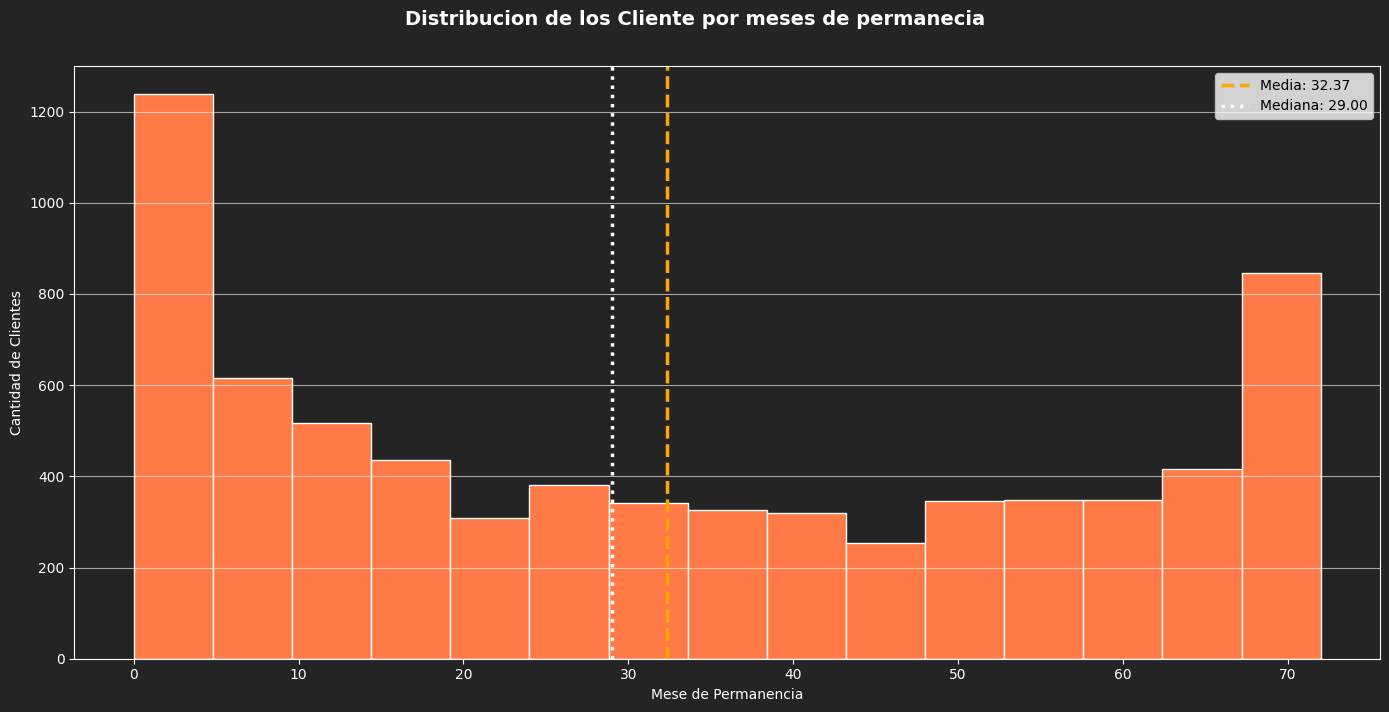

Media:     32.371
Mediana:   29.000
Std:       24.559
Asimetria: 0.240  (sesgado a la derecha)
Curtosis:  -1.387  (Leptocurtica)


In [39]:
fig, axes = plt.subplots(figsize=(14,7), facecolor='#242424')

fig.suptitle('Distribucion de los Cliente por meses de permanecia',
             fontsize=14, fontweight='bold', color="white", y=1.01)

# Calculo de Mediana y Media de los mese de permancia.
media   = df_nuevo['tenure'].mean()
mediana = df_nuevo['tenure'].median()
#carga de datos para el grafico
axes.hist(df_nuevo['tenure'], bins=15, color="#FF7A47",
             edgecolor='white', alpha=1, linewidth=1.0)
# parametro para la visualizacion del grafico
axes.axvline(media,   color='#FFA600',  lw=2.5, ls='--', label=f'Media: {media:.2f}')
axes.axvline(mediana, color='white', lw=2.5, ls=':',  label=f'Mediana: {mediana:.2f}')
axes.set_facecolor('#242424')
for spine in axes.spines.values():
    spine.set_color('white')
axes.set_xlabel('Mese de Permanencia', color='white')
axes.set_ylabel('Cantidad de Clientes', color='white')
axes.legend(fontsize=10)
axes.grid(axis='y', alpha=0.6, color='white' )
axes.tick_params(axis='x', colors='white')
axes.tick_params(axis='y', colors='white')
plt.tight_layout()
plt.show()

print(f'Media:     {media:.3f}')
print(f'Mediana:   {mediana:.3f}')
print(f'Std:       {df_nuevo["tenure"].std():.3f}')
print(f'Asimetria: {df_nuevo["tenure"].skew():.3f}  '
      f'({"sesgado a la izquierda" if df_nuevo["tenure"].skew() < 0 else "sesgado a la derecha"})')
print(f'Curtosis:  {df_nuevo["tenure"].kurtosis():.3f}  '
      f'({"Leptocurtica" if df_nuevo["tenure"].kurtosis() < 0 else "Platicurtica"})')

se logra identificar  2 perfiles de clientes predominantes al extremo clientes nuevos con un maximo de 5 meses de permanencia y clientes muy antiguos con 68 a 72 meses de permanencia, lo cuales representan una base de clientes sumamente leasles. Asi tambien se logra apreciar la barrera critica de los 5 meses, luego los cliente abandonan el servicio, puede ser acausa se estaban probando el serviocio y este no cumplio con las expectativas.

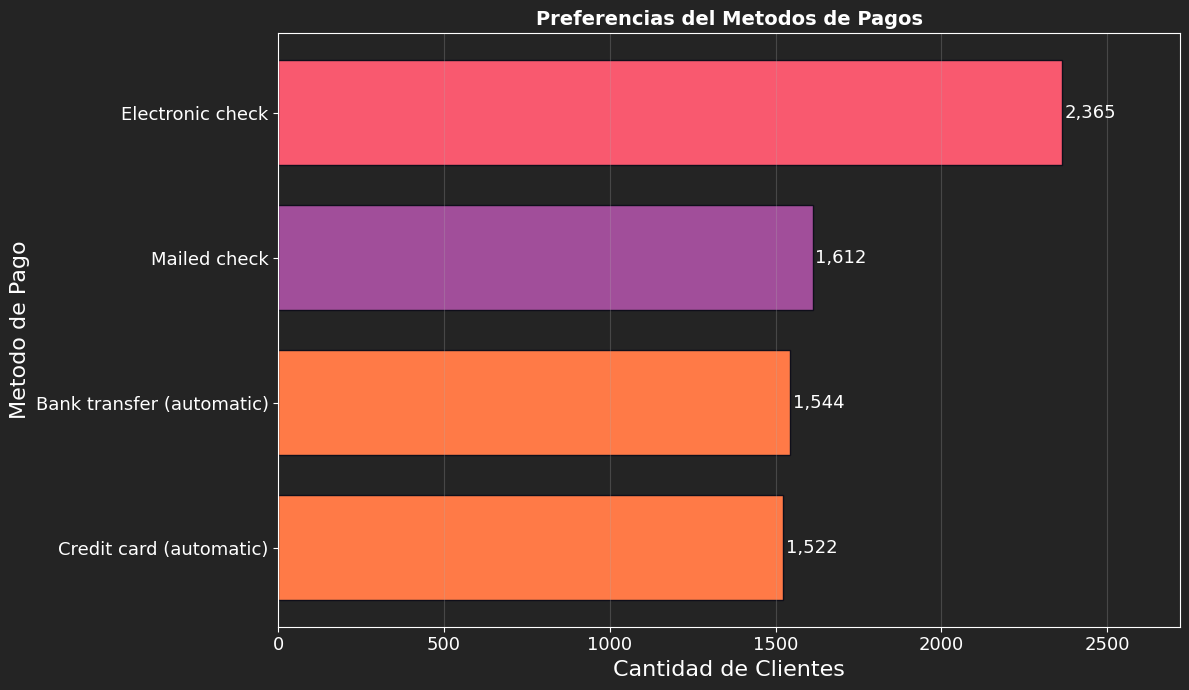

Total de metodos de pago: 4

Porcentaje de preferencia por metodo de pago:
  Electronic check: 2365 clientes (33.6%)
  Mailed check: 1612 clientes (22.9%)
  Bank transfer (automatic): 1544 clientes (21.9%)
  Credit card (automatic): 1522 clientes (21.6%)


In [40]:
# obtencion valores para la variable categorias
top_cats = df_nuevo['PaymentMethod'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7), facecolor='#242424')

colores = ['#F9596F' if i < 1 else '#A14E9A' if i < 2 else '#FF7A47' for i in range(len(top_cats))]

#carga de datos para el grafico
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1],
               color=colores[::-1], edgecolor='#0F0F1A', height=0.72)

for bar, val in zip(bars, top_cats.values[::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=13, color='white')
# parametro para la visualizacion del grafico
ax.set_title('Preferencias del Metodos de Pagos', fontsize=14,
             fontweight='bold', color='white')
ax.set_xlabel('Cantidad de Clientes', color='white', fontsize=16)
ax.set_ylabel('Metodo de Pago', color='white', fontsize=16)
ax.tick_params(axis='x', colors='white', labelsize=13)
ax.tick_params(axis='y', colors='white', labelsize=13)
ax.set_facecolor('#242424')
for spine in ax.spines.values():
    spine.set_color('white')
ax.set_xlim(0, top_cats.max() * 1.15)
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Total de metodos de pago: {df_nuevo["PaymentMethod"].nunique()}')
print(f'\nPorcentaje de preferencia por metodo de pago:')
for cat, cnt in top_cats.items():
    print(f'  {cat}: {cnt} clientes ({cnt/len(df)*100:.1f}%)')

Se logra apreciar  que la preferencia recae en el metodo de pago Electronic Check, por lo cual se infiere que la mayor parte de la operacion y los ingresos depende de este metodo de pago, bien en pasis donde este metodo de pago es comun y preferido no tiene un mayor riego, sin embargo en chile este tipo de metodo podria poner en riego las operacion de una TELECOM.

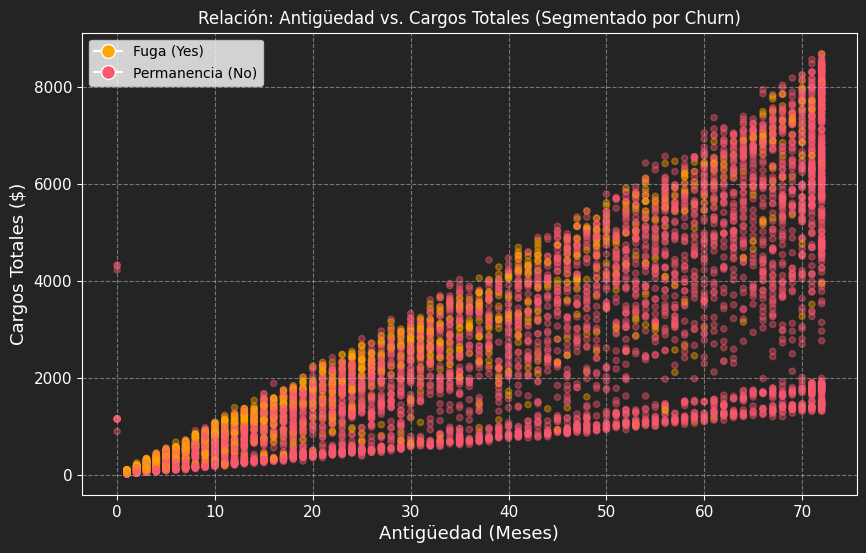

In [41]:
# Creacion de serie con el color de visualizacion para el  punto
colors = df_nuevo['Churn'].map({'Yes': '#FFA600', 'No': '#F9596F'})

plt.figure(figsize=(10, 6), facecolor='#242424')

#carga de datos para el grafico
plt.scatter(df_nuevo['tenure'], df_nuevo['TotalCharges'], c=colors, alpha=0.4, s=20)

# parametro para la visualizacion del grafico
plt.title('Relación: Antigüedad vs. Cargos Totales (Segmentado por Churn)', color='white')
plt.xlabel('Antigüedad (Meses)', color='white', fontsize=13)
plt.tick_params(axis='x', colors='white', labelsize=11)
plt.tick_params(axis='y', colors='white', labelsize=11)
plt.gca().set_facecolor('#242424')
for spine in plt.gca().spines.values():
    spine.set_color('white')
plt.ylabel('Cargos Totales ($)', color='white', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Fuga (Yes)', markerfacecolor='#FFA600', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Permanencia (No)', markerfacecolor='#F9596F', markersize=10)]
plt.legend(handles=legend_elements)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Este gráfico multivariado permite visualizar el "valor de vida" del cliente. La concentración de puntos Naranja en la parte inferior izquierda sugiere que la fuga ocurre principalmente en clientes nuevos con bajo gasto acumulado. La línea ascendente rosada muestra la trayectoria ideal de un cliente leal y rentable.

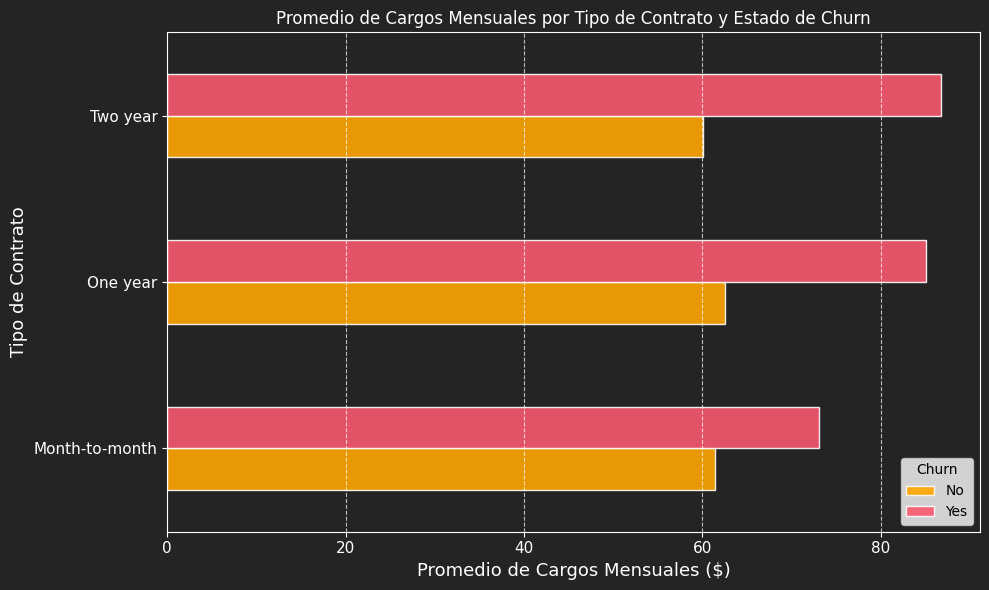

In [42]:
# Calculo del promedio de Cargos mensuales por contrato y permanencia
data_grouped = df_nuevo.groupby(['Contract', 'Churn'])['MonthlyCharges'].mean().unstack()

#carga de datos para el grafico
ax = data_grouped.plot(kind='barh', figsize=(10, 6), color=['#FFA600', '#F9596F'], edgecolor='white', alpha=0.9)

# parametro para la visualizacion del grafico
ax.figure.set_facecolor('#242424')
ax.figure.set_alpha(0.2)
ax.set_facecolor('#242424')
ax.set_title('Promedio de Cargos Mensuales por Tipo de Contrato y Estado de Churn', color='white')
ax.set_xlabel('Promedio de Cargos Mensuales ($)', color='white', fontsize=13)
ax.set_ylabel('Tipo de Contrato', color='white', fontsize=13)
ax.tick_params(axis='x', colors='white', labelsize=11)
ax.tick_params(axis='y', colors='white', labelsize=11)
legend_obj = ax.legend(title='Churn')
legend_obj.get_title().set_color('black')
for text in legend_obj.get_texts():
    text.set_color('black')
for spine in ax.spines.values():
    spine.set_color('white')
ax.grid(axis='x', linestyle='--', alpha=0.7, color='white')
plt.tight_layout()
plt.show()

Esta visualización permite comparar simultáneamente tres variables. Se observa que en cada tipo de contrato, los clientes que se fugan (Yes) tienen en promedio cargos mensuales más altos que aquellos que permanecen (No). Esto sugiere que el costo del servicio es un factor determinante en la decisión de abandono.

In [43]:
print('=' * 60)
print('RESUMEN FINAL DEL ANALISIS')
print('=' * 60)

n_orig = df_nuevo.shape  # filas originales del dataset
print(f"""
Dataset original (Telco Customer Churn): {n_orig[0]} filas x {n_orig[1]} columnas

Limpieza realizada:
  1. Conversion de tipos:
     - Reemplaza los valores 'Yes o 1' por 'True' y 'No o 0' por 'False' en la columna  'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling' del
     - Se realiza en cambio de tipo de dato a las columnas 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling' Booleano
     - Se realiza en cambio de tipo de dato a la columna 'TotalCharges' a float

  2. Duplicados eliminados: 0
      - No existen duplicados en el dataset basando en el customerID

  3. Inconsistencias:
     - Filas corrompidas en la columna 'TotalCharges' con valores NaN

  4. Nulos imputados:
     - Datos NaN = 0.16% del DataFrame, 11 datos de la columna 'TotalCharges'
     - Datos Imputados con la mediana de TotalCharges por Contract y PaymentMethod


Dataset limpio: {len(df)} filas x {df_nuevo.shape[1]} columnas
Nulos totales: {df_nuevo.isnull().sum().sum()}

Hallazgos EDA:
  1. Clientes nuevos con un maximo de 5 meses de permanencia, posibles problemas en la campaña de retencio o cliente proban el servicio.
  2. La base de los ingreso provienen a travez del metodo de pago "Electronic Check", metodo utilizado por 2365 y que en este momento representa la mayo y mas importante funte de ingreso, sin duda la eliminacion de este metodo afectaria operacional y financieramente a la TELCOM.
  3. La base de cliente mas fieles llega a ese punto debido a a que son mas rentables que los usuarios nuevos en base al promedio de los cargos mensuales.
  4. La fuga de clientes ocurre principalmente en clientes nuevos con bajo gasto acumulado.

Recomendaciones:
  -> generar campañas de fidelizacion o retencion que le permitan traslada parte de la masa de cliente nuevos (0-5 meses) a clientes con mayo anttiguedad.
""")

RESUMEN FINAL DEL ANALISIS

Dataset original (Telco Customer Churn): 7043 filas x 21 columnas

Limpieza realizada:
  1. Conversion de tipos:
     - Reemplaza los valores 'Yes o 1' por 'True' y 'No o 0' por 'False' en la columna  'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling' del
     - Se realiza en cambio de tipo de dato a las columnas 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling' Booleano
     - Se realiza en cambio de tipo de dato a la columna 'TotalCharges' a float

  2. Duplicados eliminados: 0
      - No existen duplicados en el dataset basando en el customerID

  3. Inconsistencias:
     - Filas corrompidas en la columna 'TotalCharges' con valores NaN

  4. Nulos imputados:
     - Datos NaN = 0.16% del DataFrame, 11 datos de la columna 'TotalCharges'
     - Datos Imputados con la mediana de TotalCharges por Contract y PaymentMethod


Dataset limpio: 7043 filas x 21 columnas
Nulos totales: 0

Hallazgos EDA:
  1. Cliente

## Material de Apoyo y Codigo Reutilizado

Material de Apoyo y Codigo - Más_funcionalidades_de_Pandas_04_05_2026.ipynb

[Link](https://github.com/jeedorsa/Bootcamp-Data-Science/blob/Sonda2026/Clases/3-Matplotlib/3-SimulacroExamen.ipynb)

Autor: Jesus Ortiz.


Material de Apoyo y Codigo - Más_funcionalidades_de_Pandas_04_05_2026.ipynb

[Link](https://colab.research.google.com/drive/1W_IdSVhEe9VLpoNJyrq2OhVQstgQHqLb#scrollTo=9h7ZxDEv9AIT)

Autor: Cristian Sanchez.

## Fuentes

Adobe. (s.f.). Rueda de color. Adobe Color. https://color.adobe.com/es/create/color-wheel

GeeksforGeeks. (2025, 11 de julio). Change data type for one or more columns in Pandas DataFrame. https://www.geeksforgeeks.org/pandas/change-data-type-for-one-or-more-columns-in-pandas-dataframe/

jeedorsa. (s.f.). 3-SimulacroExamen.ipynb [Jupyter Notebook]. GitHub. https://github.com/jeedorsa/Bootcamp-Data-Science/blob/Sonda2026/Clases/3-Matplotlib/3-SimulacroExamen.ipynb

The Matplotlib Development Team. (s.f.). Gallery. Matplotlib. https://matplotlib.org/stable/gallery/index.html

The Matplotlib Development Team. (s.f.). Unchained. Matplotlib. https://matplotlib.org/stable/gallery/animation/unchained.html

pandas Development Team. (2024). pandas.DataFrame.convert_dtypes — pandas 3.0.2 documentation. pandas. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.convert_dtypes.html

pandas Development Team. (2024). pandas.get_dummies — pandas 3.0.1 documentation. pandas. https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html

pandas Development Team. (2024). pandas.to_numeric — pandas 3.0.2 documentation. pandas. https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html

R-Charts. (s.f.). Generador de paletas de colores. r-charts.com. https://r-charts.com/es/generador-paletas-colores/

Scipy Lectures Contributors. (s.f.). Code samples for Matplotlib. Scipy Lecture Notes. https://scipy-lectures.org/intro/matplotlib/auto_examples/

Kennedy, E. D. (s.f.). The data viz color picker. Learn UI Design. https://www.learnui.design/tools/data-color-picker.html